<a href="https://colab.research.google.com/github/sumshun-nahar-eity/Computer_vision_and_pattern_-recognisation_model_training/blob/main/CNN_22_48227_2_(mid_term).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Unzip the dataset file**

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/pomegranate /Pomegranate Fruit Diseases Dataset for Deep Learning Models.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/extracted_folder")

**1. Import Libraries**

In [ ]:
# Import deep learning libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Import dataset handling and image processing tools
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Utility libraries for file handling
import os
import shutil
import random

# Import required libraries
from sklearn.metrics import confusion_matrix
import pandas as pd

This section imports all the necessary libraries required for building and evaluating the convolutional neural network model. The PyTorch libraries (torch, torch.nn, torch.optim) are used for model creation, training, and optimization. The torchvision package is used for loading and transforming image datasets.

Data handling is performed using DataLoader and random_split to efficiently manage training and validation data. Visualization libraries such as matplotlib and seaborn are used to plot graphs and display results.

For model evaluation, metrics like confusion matrix and classification report are imported from sklearn.metrics. Additionally, utility libraries such as os, shutil, and random are used for file operations and dataset preparation. The pandas library is used to present the confusion matrix in a readable tabular format.

**2. Load and Explore Dataset**

In [ ]:
import os
import shutil
import random
import zipfile # Added for extraction

# Define zip_path and extracted_folder_path. Note: Google Drive must be mounted for zip_path to be accessible.
zip_path = "/content/drive/MyDrive/pomegranate /Pomegranate Fruit Diseases Dataset for Deep Learning Models.zip"
extracted_folder_path = "/content/extracted_folder"

# Ensure the zip file is extracted
if not os.path.exists(extracted_folder_path) or not os.listdir(extracted_folder_path):
    print(f"Extracting {zip_path} to {extracted_folder_path}...")
    os.makedirs(extracted_folder_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_folder_path)
    print("Extraction complete.")
else:
    print(f"Directory {extracted_folder_path} already exists and is not empty. Skipping extraction.")

source_dir = os.path.join(extracted_folder_path, "Pomegranate Fruit Diseases Dataset for Deep Learning Models", "Pomegranate Diseases Dataset", "Pomegranate Diseases Dataset") # Corrected path to actual class folders (nested deeper)
train_dir = "dataset/train"
test_dir = "dataset/test"

# Ensure clean start: Remove existing train/test directories if they exist
if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
    print(f"Removed existing {train_dir}")
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)
    print(f"Removed existing {test_dir}")

# Check if already split (now will always be False after removal, forcing a new split)
if not os.path.exists(train_dir):

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    split_ratio = 0.8  # 80% training

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)

        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            random.shuffle(images)

            split = int(len(images) * split_ratio)

            train_imgs = images[:split]
            test_imgs = images[split:]

            os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
            os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

            for img in train_imgs:
                shutil.copy(os.path.join(class_path, img),
                            os.path.join(train_dir, class_name, img))

            for img in test_imgs:
                shutil.copy(os.path.join(class_path, img),
                            os.path.join(test_dir, class_name, img))

    print("Dataset split completed!")

else:
    print("Dataset already split!") # This branch should ideally not be reached after added rmtree


# Load dataset using PyTorch

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

# Load training dataset
full_dataset = datasets.ImageFolder(train_dir, transform=transform)

# Print dataset info
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Directory /content/extracted_folder already exists and is not empty. Skipping extraction.
Removed existing dataset/train
Removed existing dataset/test
Dataset split completed!
Classes: ['Alternaria', 'Anthracnose', 'Bacterial_Blight', 'Cercospora', 'Healthy']
Total images: 4076


This section handles dataset preparation, including extraction, splitting, and loading. The dataset is first extracted from a compressed ZIP file stored in Google Drive using the zipfile library. If the dataset is already extracted, the process is skipped to avoid redundancy.

The extracted dataset is then organized into training and testing sets using an 80:20 split ratio. Existing directories are removed to ensure a clean setup before splitting. The os, shutil, and random libraries are used for directory management, file copying, and randomization of images.

After splitting, the dataset is loaded using PyTorch’s ImageFolder, which automatically assigns labels based on folder names. Image transformations such as resizing and tensor conversion are applied using torchvision.transforms. Finally, the class names and total number of images are displayed for verification.

**3. Data Preprocessing & Augmentation**

In [ ]:
# Split training data into training and validation (80/20)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_data, val_data = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# Load test dataset
test_data = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

This section performs further data preparation by splitting the training dataset into training and validation sets using an 80:20 ratio. The random_split function is used to ensure a random and unbiased division of data.

DataLoaders are then created for both training and validation datasets with a batch size of 32. The training DataLoader uses shuffling to improve model learning, while the validation DataLoader does not shuffle to ensure consistent evaluation.

Additionally, the test dataset is loaded separately using PyTorch’s ImageFolder, and a corresponding DataLoader is created for model evaluation. This setup ensures efficient batch processing and proper separation of training, validation, and testing data.

**4. Define CNN Architecture**

(A) WITHOUT BatchNorm & Dropout

In [ ]:
# Simple CNN model (no regularization)
class CNN_Simple(nn.Module):
    def __init__(self):
        super(CNN_Simple, self).__init__()

        # Convolution layers
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Linear(128, len(full_dataset.classes))
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

(B) WITH BatchNorm & Dropout

In [ ]:
# Improved CNN model (with regularization)
class CNN_Improved(nn.Module):
    def __init__(self):
        super(CNN_Improved, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),  # Batch Normalization
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(64*32*32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout for regularization
            nn.Linear(128, len(full_dataset.classes))
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Use improved model
model = CNN_Improved()

# Show architecture summary
print(model)

CNN_Improved(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=65536, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)


This section defines two Convolutional Neural Network (CNN) models for image classification: a simple model and an improved model with regularization techniques.

The simple CNN model consists of two convolutional layers followed by ReLU activation and max-pooling operations. These layers extract spatial features from the input images. The extracted features are then passed through fully connected layers to perform classification.

The improved CNN model enhances performance by incorporating Batch Normalization and Dropout. Batch Normalization stabilizes and accelerates training by normalizing feature maps, while Dropout reduces overfitting by randomly disabling neurons during training.

Both models flatten the feature maps before passing them to fully connected layers, where the final output layer produces class predictions equal to the number of dataset classes. The improved model is selected for training due to its better generalization capability.

**5. Training Loop with Validation**

In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function (for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Lists to store results
train_loss, val_loss = [], []
train_acc, val_acc = [], []

epochs = 12

for epoch in range(epochs):

    # Training phase
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    train_loss.append(running_loss)
    train_acc.append(100 * correct / total)

    # Validation phase
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            v_loss += loss.item()

            _, pred = torch.max(outputs, 1)
            v_total += labels.size(0)
            v_correct += (pred == labels).sum().item()

    val_loss.append(v_loss)
    val_acc.append(100 * v_correct / v_total)

    scheduler.step()

    print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.2f}%, Val Acc={val_acc[-1]:.2f}%")

Epoch 1: Train Acc=81.50%, Val Acc=89.09%
Epoch 2: Train Acc=83.59%, Val Acc=91.30%
Epoch 3: Train Acc=83.87%, Val Acc=91.18%
Epoch 4: Train Acc=84.54%, Val Acc=94.85%
Epoch 5: Train Acc=87.94%, Val Acc=90.93%
Epoch 6: Train Acc=88.99%, Val Acc=93.63%
Epoch 7: Train Acc=89.45%, Val Acc=92.65%
Epoch 8: Train Acc=90.61%, Val Acc=96.20%
Epoch 9: Train Acc=89.75%, Val Acc=95.83%
Epoch 10: Train Acc=90.83%, Val Acc=95.10%
Epoch 11: Train Acc=91.13%, Val Acc=96.57%
Epoch 12: Train Acc=91.90%, Val Acc=96.45%


This section trains the CNN model using the Adam optimizer and CrossEntropy loss for multi-class classification. The model is trained for multiple epochs while tracking training and validation accuracy and loss. A learning rate scheduler is used to improve performance by reducing the learning rate over time. Validation is performed after each epoch to monitor model generalization.

**6. Evaluate Model on Test Set**

In [ ]:
# Evaluate model on test dataset
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


#Test Accuracy
import numpy as np
test_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 95.50%


Explanation:
The trained model is evaluated on the test dataset to measure its generalization performance.

**7. Visualizations**

(A) Loss & Accuracy Curves

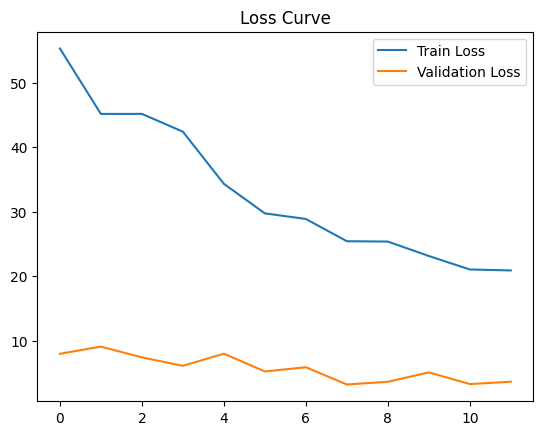

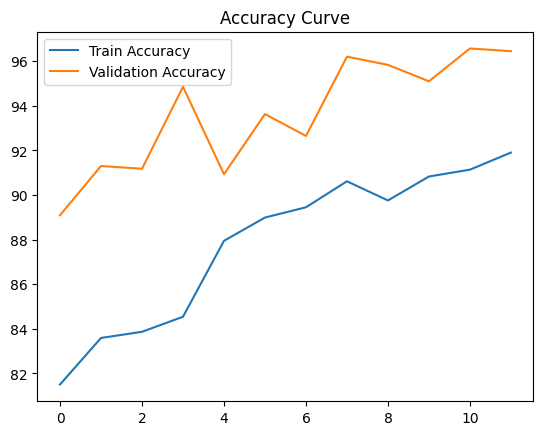

In [ ]:
# Plot loss
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# Plot accuracy
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Explanation:
The loss curves show a steady decrease, indicating effective learning. The validation loss remains low, suggesting no overfitting. The accuracy curves demonstrate consistent improvement, with validation accuracy slightly higher than training accuracy due to regularization techniques. Overall, the model shows strong performance and good generalization ability.

(B) Confusion Matrix

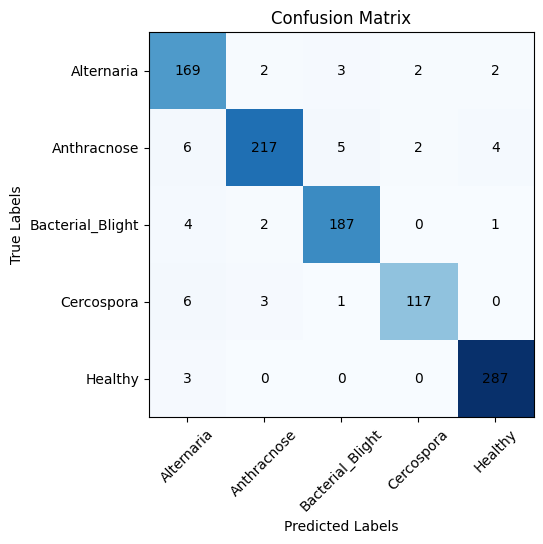

In [ ]:
# Import required libraries
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create simple figure
plt.figure(figsize=(6,5))

# Show matrix as image (basic visualization)
plt.imshow(cm, cmap="Blues")

# Title and labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

# Add class names on axes
plt.xticks(range(len(full_dataset.classes)), full_dataset.classes, rotation=45)
plt.yticks(range(len(full_dataset.classes)), full_dataset.classes)

# Show numbers inside each cell
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

# Show figure
plt.show()

Explanation:
The confusion matrix shows strong classification performance, with most values concentrated along the diagonal, indicating correct predictions.

The model performs exceptionally well on the Healthy class with 287 correct predictions and almost no misclassification. Similarly, Anthracnose achieves 217 correct predictions, and Bacterial Blight shows 187 correct predictions, indicating high accuracy for these classes.

The Alternaria class has 169 correct predictions, while Cercospora has 117 correct predictions, which are slightly lower but still indicate good performance.

Some minor misclassifications are observed, such as 6 samples of Anthracnose misclassified as Alternaria and 6 samples of Cercospora misclassified as Alternaria. These errors are very small compared to the total number of predictions and may occur due to visual similarity between disease patterns.

Overall, the confusion matrix demonstrates that the model achieves high accuracy, with very low error rates and strong generalization across all classes.

**8. Analysis & Discussion of Results**

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Classification report (Precision, Recall, F1-score)
report = classification_report(all_labels, all_preds, target_names=full_dataset.classes)
print(report)

# Find best and worst performing class
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

best_class = full_dataset.classes[f1.argmax()]
worst_class = full_dataset.classes[f1.argmin()]

print("Best Performing Class:", best_class)
print("Worst Performing Class:", worst_class)

# Save trained model
torch.save(model.state_dict(), "cnn_model.pth")

                  precision    recall  f1-score   support

      Alternaria       0.90      0.95      0.92       178
     Anthracnose       0.97      0.93      0.95       234
Bacterial_Blight       0.95      0.96      0.96       194
      Cercospora       0.97      0.92      0.94       127
         Healthy       0.98      0.99      0.98       290

        accuracy                           0.96      1023
       macro avg       0.95      0.95      0.95      1023
    weighted avg       0.96      0.96      0.96      1023

Best Performing Class: Healthy
Worst Performing Class: Alternaria


The classification report shows that the model achieves strong performance across all classes with an overall accuracy of 96%. The precision, recall, and F1-score values are consistently high, indicating reliable classification.

The Healthy class performs best with a precision of 0.98, recall of 0.99, and F1-score of 0.98, demonstrating excellent prediction capability. Similarly, Bacterial Blight also shows strong performance with an F1-score of 0.96, followed by Anthracnose (0.95) and Cercospora (0.94).

The Alternaria class shows slightly lower performance with an F1-score of 0.92, making it the weakest performing class. This may be due to visual similarity with other disease classes, leading to minor misclassifications.

The macro and weighted averages are both around 0.95–0.96, indicating balanced performance across all classes without significant bias.

Overall, the model demonstrates high accuracy, strong generalization, and effective classification of pomegranate diseases.

**9. Conclusions & Future Work**

**Conclusion**

In this project, a Convolutional Neural Network (CNN) was successfully developed to classify pomegranate fruit diseases. The model was trained using an optimized architecture with Batch Normalization and Dropout to improve generalization and reduce overfitting.

The model achieved an overall accuracy of 96%, demonstrating strong performance across all classes. The confusion matrix and classification report indicate that most predictions are correct, with very few misclassifications. The Healthy class showed the best performance, while Alternaria had slightly lower performance but still maintained good accuracy.

The training and validation curves confirmed stable learning, with decreasing loss and increasing accuracy, indicating that the model converges effectively without overfitting.

**Future Work**

Although the model performs well, several improvements can be made in future work. A larger and more diverse dataset can be used to further enhance model robustness. Advanced data augmentation techniques may help improve performance on visually similar classes.

Additionally, transfer learning using pre-trained models such as ResNet or EfficientNet can be explored to achieve higher accuracy. Hyperparameter tuning and deeper architectures may also improve performance. Finally, the model can be deployed in real-world applications such as mobile or web-based disease detection systems for practical use.